<a href="https://www.kaggle.com/code/lalit7881/credit-card-fraud-detection-2026-eda-98-32?scriptVersionId=336859966" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv")

In [3]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [4]:
df.tail()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
19995,19996,41.40,Healthcare,Mastercard,OTP,POS,Android Phone,False,8.82,2,...,False,False,0,17.3,2,3,False,29.6,1,0
19996,19997,47.92,Online Retail,Visa,OTP,POS,Android Phone,False,45.81,1,...,False,False,0,9.0,4,0,False,29.2,1,0
19997,19998,10.25,Restaurants,Visa,3D Secure,In-App,Tablet,False,20.67,0,...,False,False,1,1.0,19,5,False,22.9,0,0
19998,19999,31.34,Travel,Visa,3D Secure,Online,Android Phone,False,22.94,2,...,False,False,0,8.8,2,1,False,27.9,0,0
19999,20000,47.70,Online Retail,Mastercard,Biometric,Online,iPhone,False,1.20,6,...,False,False,0,41.9,0,6,False,14.4,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [6]:
df.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [7]:
df.isnull()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [9]:
df.dtypes

transaction_id                    int64
amount_usd                      float64
merchant_category                object
card_type                        object
auth_method                      object
channel                          object
device_type                      object
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months                   int64
customer_age                      int64
account_balance_usd             float64
is_new_merchant                    bool
used_vpn                           bool
ip_country_mismatch                bool
billing_shipping_mismatch          bool
cvv_retry_count                   int64
velocity_score                  float64
time_of_day_hour                  int64
day_of_week                       int64
is_ai_generated_scam_attempt       bool
merchant_risk_score             float64
prior_disputes                    int64


In [10]:
df.shape

(20000, 26)

In [11]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')

In [12]:
df.nunique()

transaction_id                  20000
amount_usd                      12782
merchant_category                  12
card_type                           5
auth_method                         5
channel                             5
device_type                         8
is_foreign_transaction              2
hours_since_last_txn             3296
txn_count_last_24h                 13
distance_from_home_km            6121
card_age_months                    52
customer_age                       64
account_balance_usd             19629
is_new_merchant                     2
used_vpn                            2
ip_country_mismatch                 2
billing_shipping_mismatch           2
cvv_retry_count                     4
velocity_score                    634
time_of_day_hour                   24
day_of_week                         7
is_ai_generated_scam_attempt        2
merchant_risk_score               940
prior_disputes                      5
is_fraud                            2
dtype: int64

In [13]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Figure Size
plt.rcParams["figure.figsize"]=(10,6)

# Color Palette
colors = ["#FF6B6B","#4ECDC4","#45B7D1","#96CEB4","#FFEAA7",
          "#DDA0DD","#00B894","#0984E3","#E17055","#6C5CE7",
          "#FDCB6E","#2ECC71","#E84393","#A29BFE","#00CEC9"]

# Load Dataset
# df = pd.read_csv("fraud_detection.csv")

print(df.head())

   transaction_id  amount_usd merchant_category   card_type  \
0               1       42.86       Restaurants        Visa   
1               2        4.75     Online Retail  Mastercard   
2               3       77.18         Groceries  Mastercard   
3               4        1.69         Streaming        Visa   
4               5      261.68            Travel        Visa   

         auth_method channel    device_type  is_foreign_transaction  \
0                OTP  Online  Android Phone                   False   
1          3D Secure  Online  Android Phone                   False   
2          3D Secure  Online            Mac                   False   
3  No Authentication     POS  Android Phone                   False   
4          3D Secure  In-App         iPhone                   False   

   hours_since_last_txn  txn_count_last_24h  ...  ip_country_mismatch  \
0                 13.54                   2  ...                False   
1                  0.71                   2  ...

In [14]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object','category','bool']).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['transaction_id', 'amount_usd', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')

Categorical Columns
Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type', 'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
       'ip_country_mismatch', 'billing_shipping_mismatch',
       'is_ai_generated_scam_attempt'],
      dtype='object')


## EDA

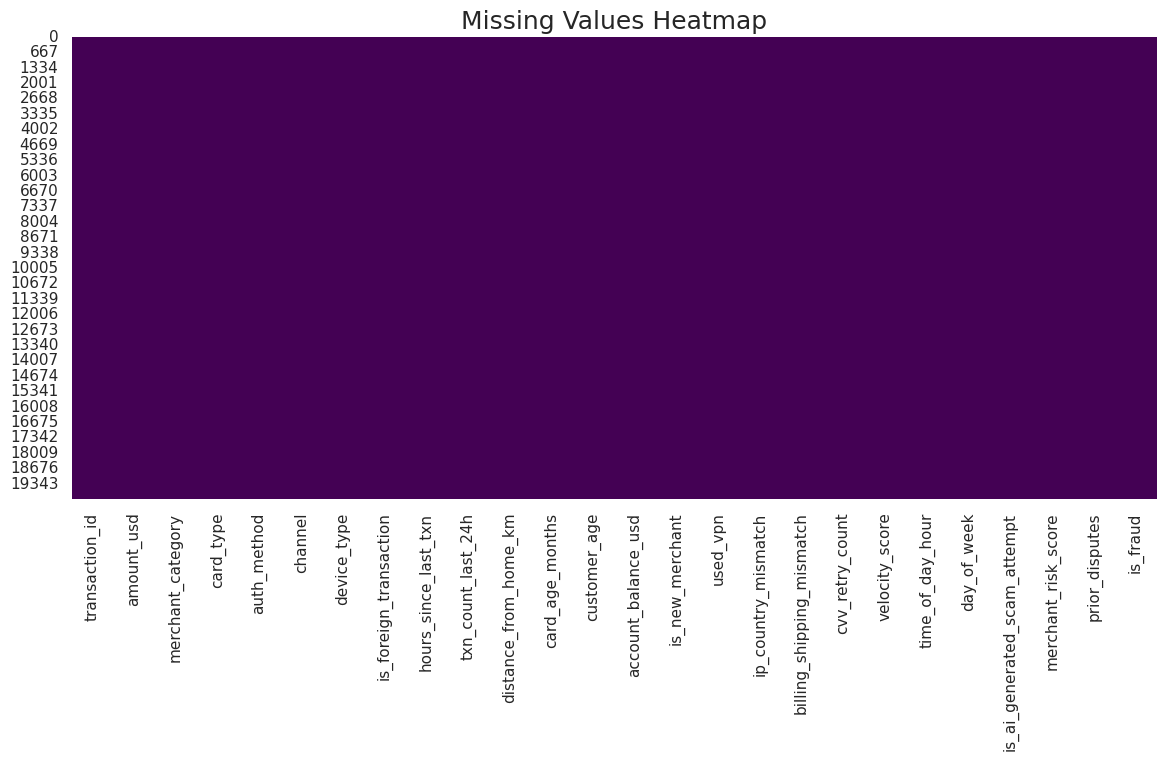

In [15]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),cmap="viridis",cbar=False)
plt.title("Missing Values Heatmap",fontsize=18)
plt.show()

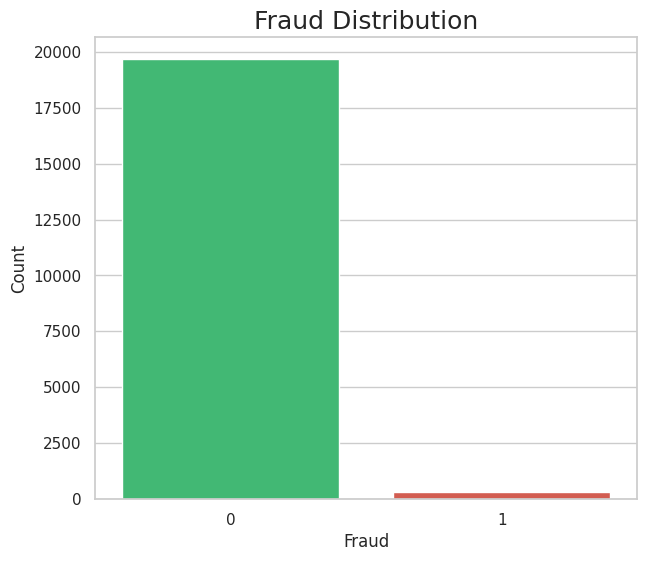

In [16]:
plt.figure(figsize=(7,6))

sns.countplot(
    data=df,
    x="is_fraud",
    palette=["#2ECC71","#E74C3C"]
)

plt.title("Fraud Distribution",fontsize=18)
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

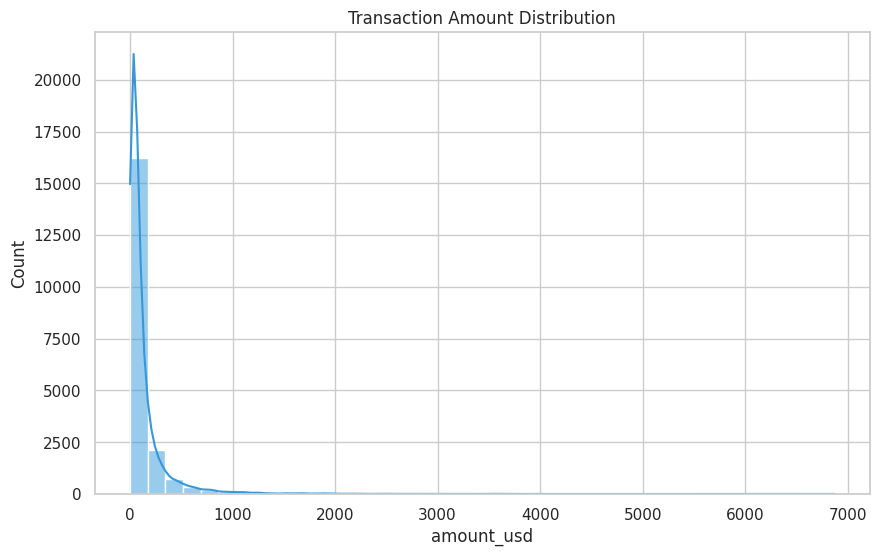

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["amount_usd"],
    bins=40,
    kde=True,
    color="#3498DB"
)

plt.title("Transaction Amount Distribution")
plt.show()

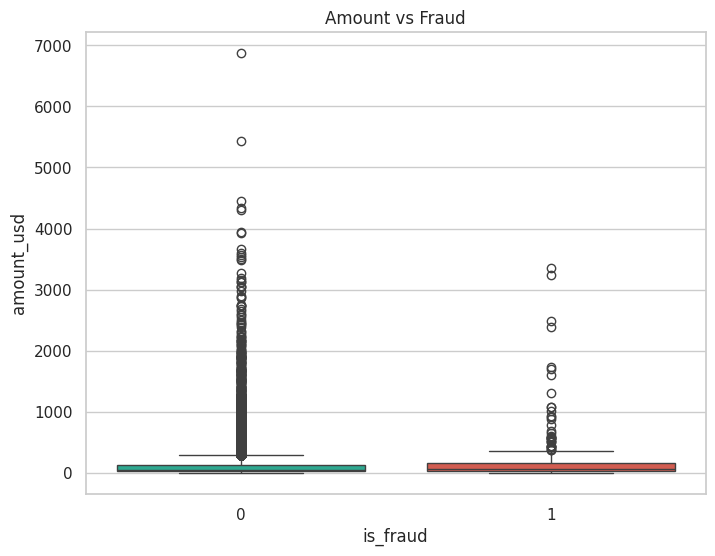

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount_usd",
    palette=["#1ABC9C","#E74C3C"]
)

plt.title("Amount vs Fraud")

plt.show()

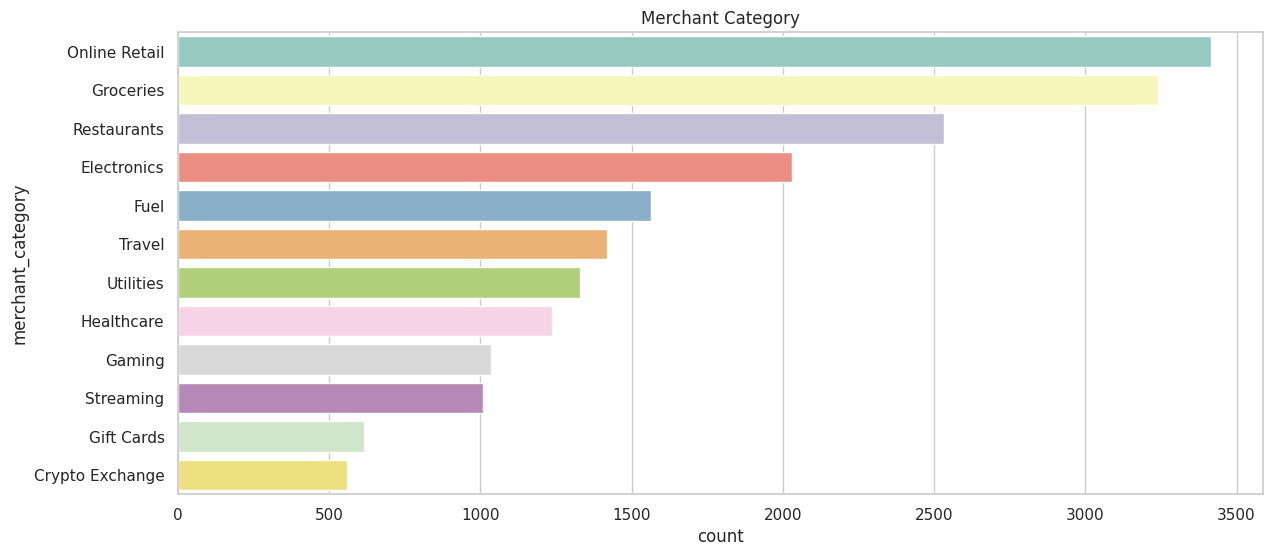

In [19]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="merchant_category",
    order=df["merchant_category"].value_counts().index,
    palette="Set3"
)

plt.title("Merchant Category")

plt.show()

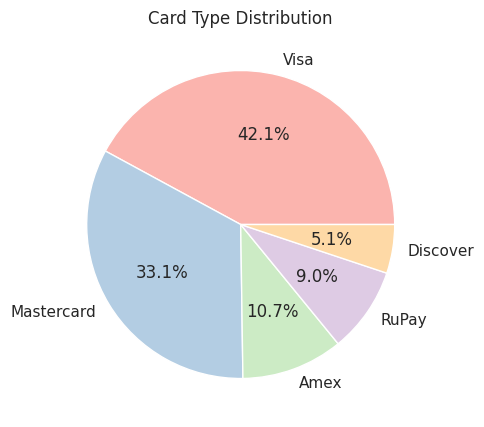

In [20]:
plt.figure(figsize=(8,5))

df["card_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=sns.color_palette("Pastel1")
)

plt.ylabel("")
plt.title("Card Type Distribution")

plt.show()

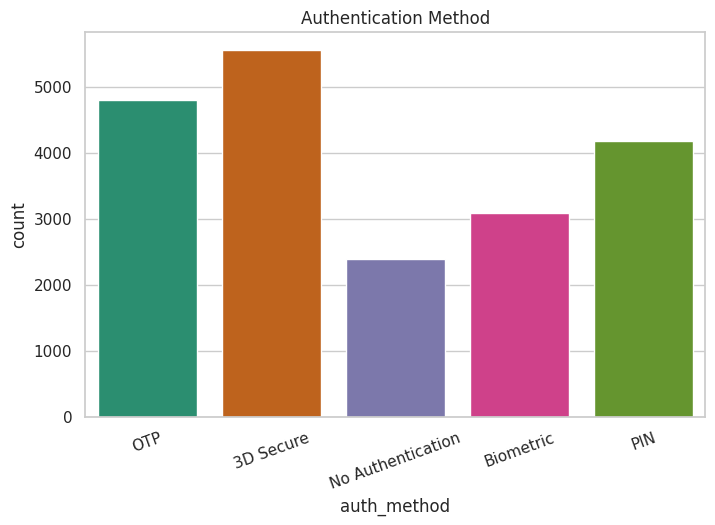

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="auth_method",
    palette="Dark2"
)

plt.title("Authentication Method")

plt.xticks(rotation=20)

plt.show()

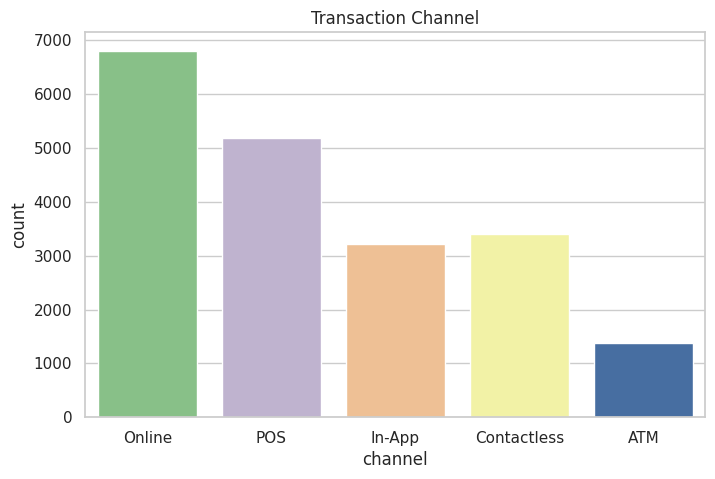

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="channel",
    palette="Accent"
)

plt.title("Transaction Channel")

plt.show()

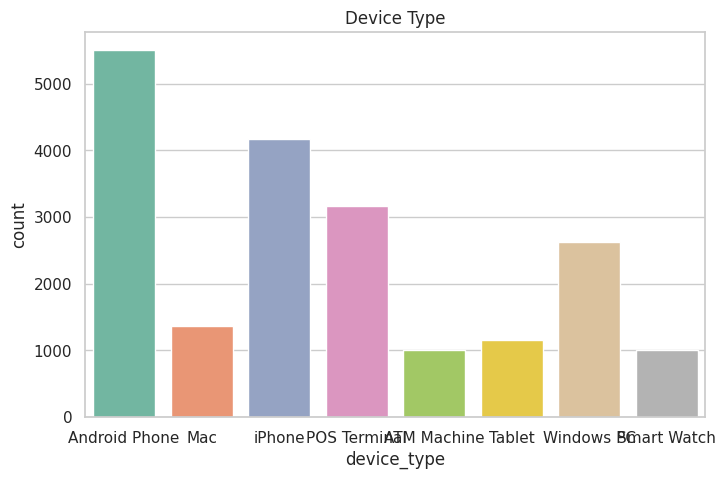

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="device_type",
    palette="Set2"
)

plt.title("Device Type")

plt.show()

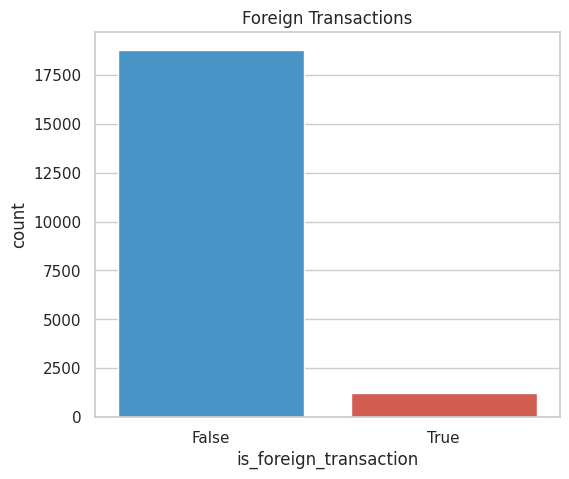

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="is_foreign_transaction",
    palette=["#3498DB","#E74C3C"]
)

plt.title("Foreign Transactions")

plt.show()

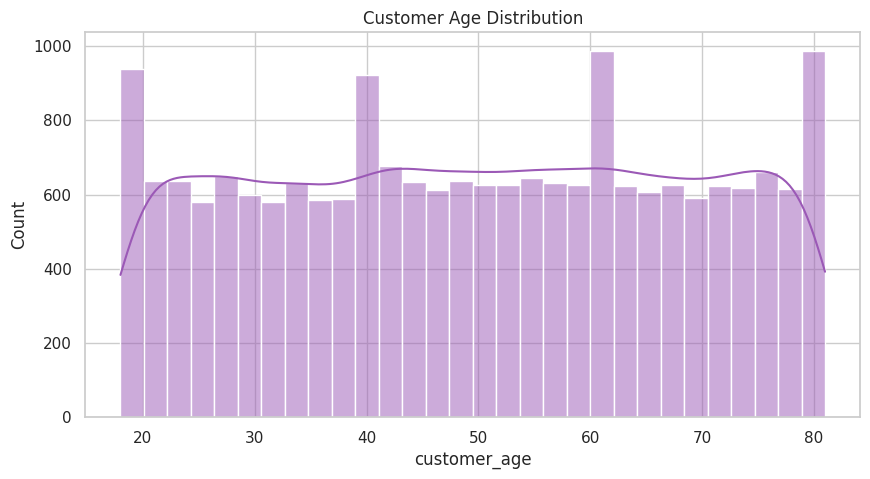

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["customer_age"],
    bins=30,
    color="#9B59B6",
    kde=True
)

plt.title("Customer Age Distribution")

plt.show()

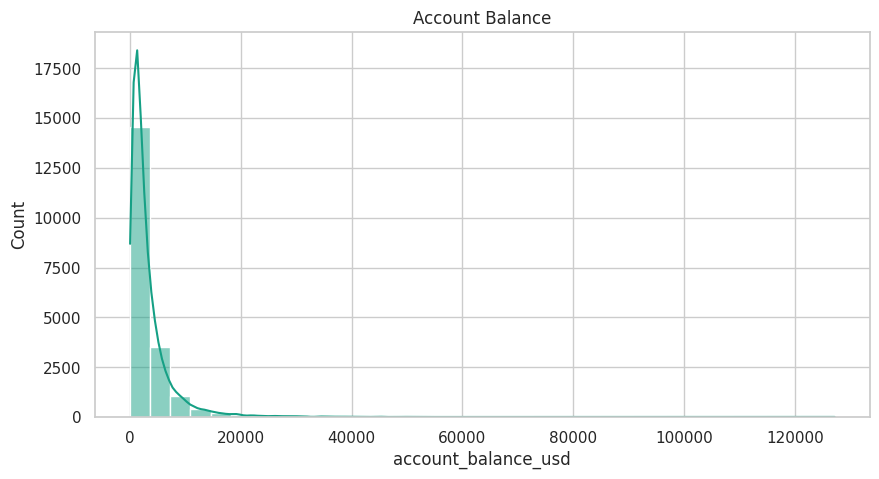

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["account_balance_usd"],
    bins=35,
    color="#16A085",
    kde=True
)

plt.title("Account Balance")

plt.show()

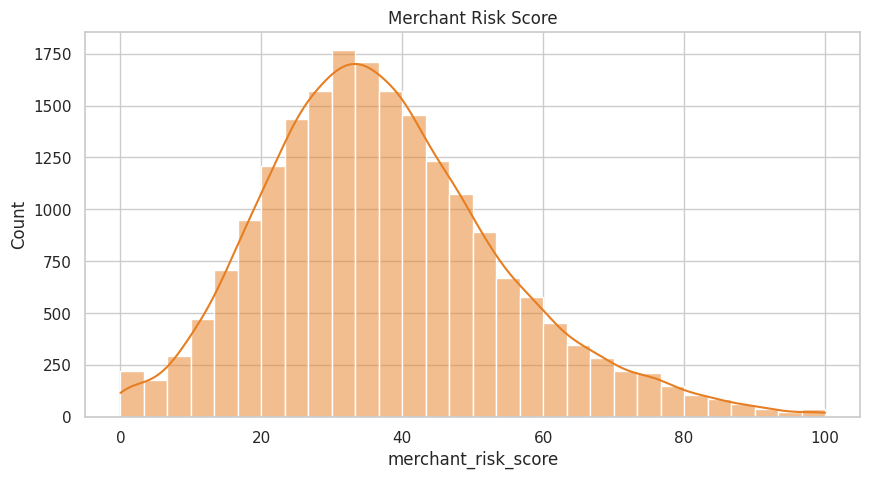

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["merchant_risk_score"],
    bins=30,
    color="#E67E22",
    kde=True
)

plt.title("Merchant Risk Score")

plt.show()

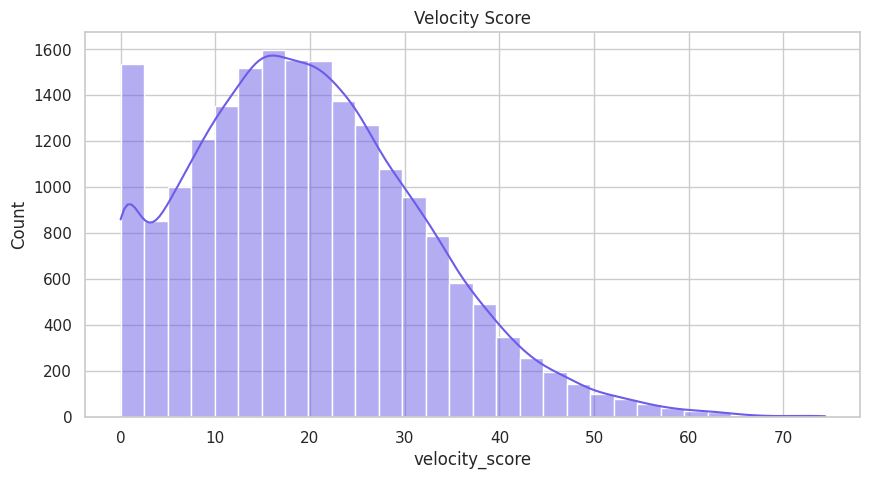

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["velocity_score"],
    bins=30,
    color="#6C5CE7",
    kde=True
)

plt.title("Velocity Score")

plt.show()

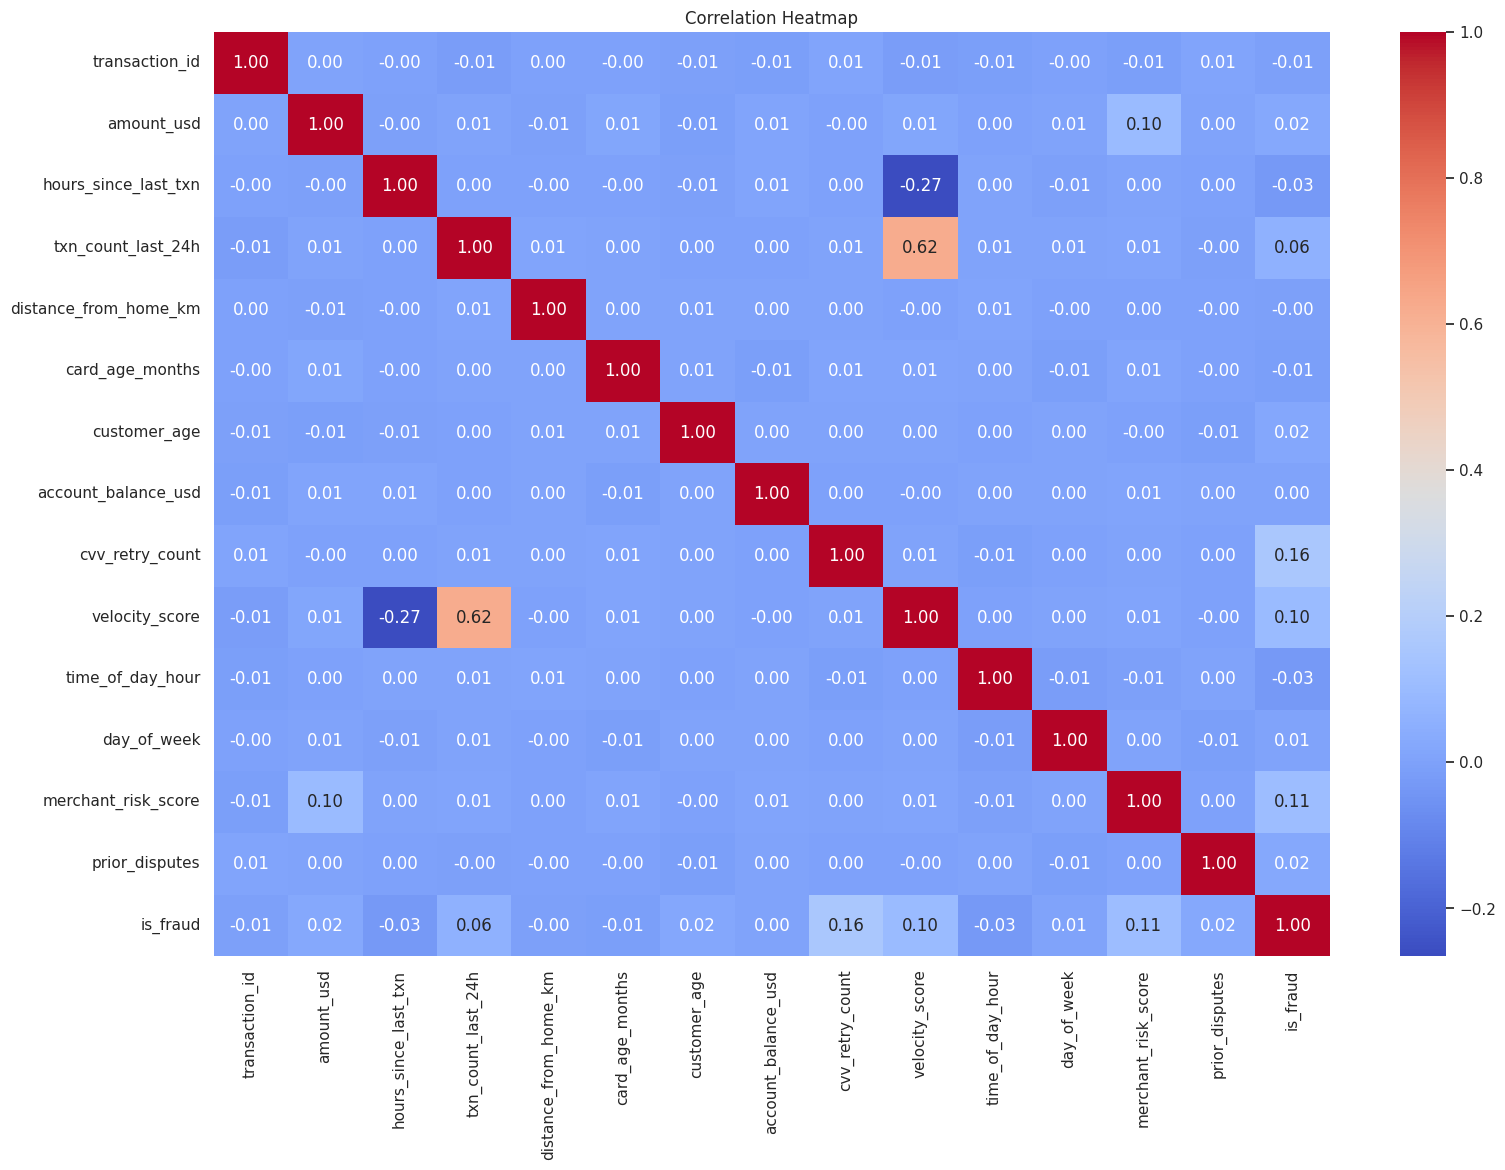

In [29]:
plt.figure(figsize=(18,12))

corr=df[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

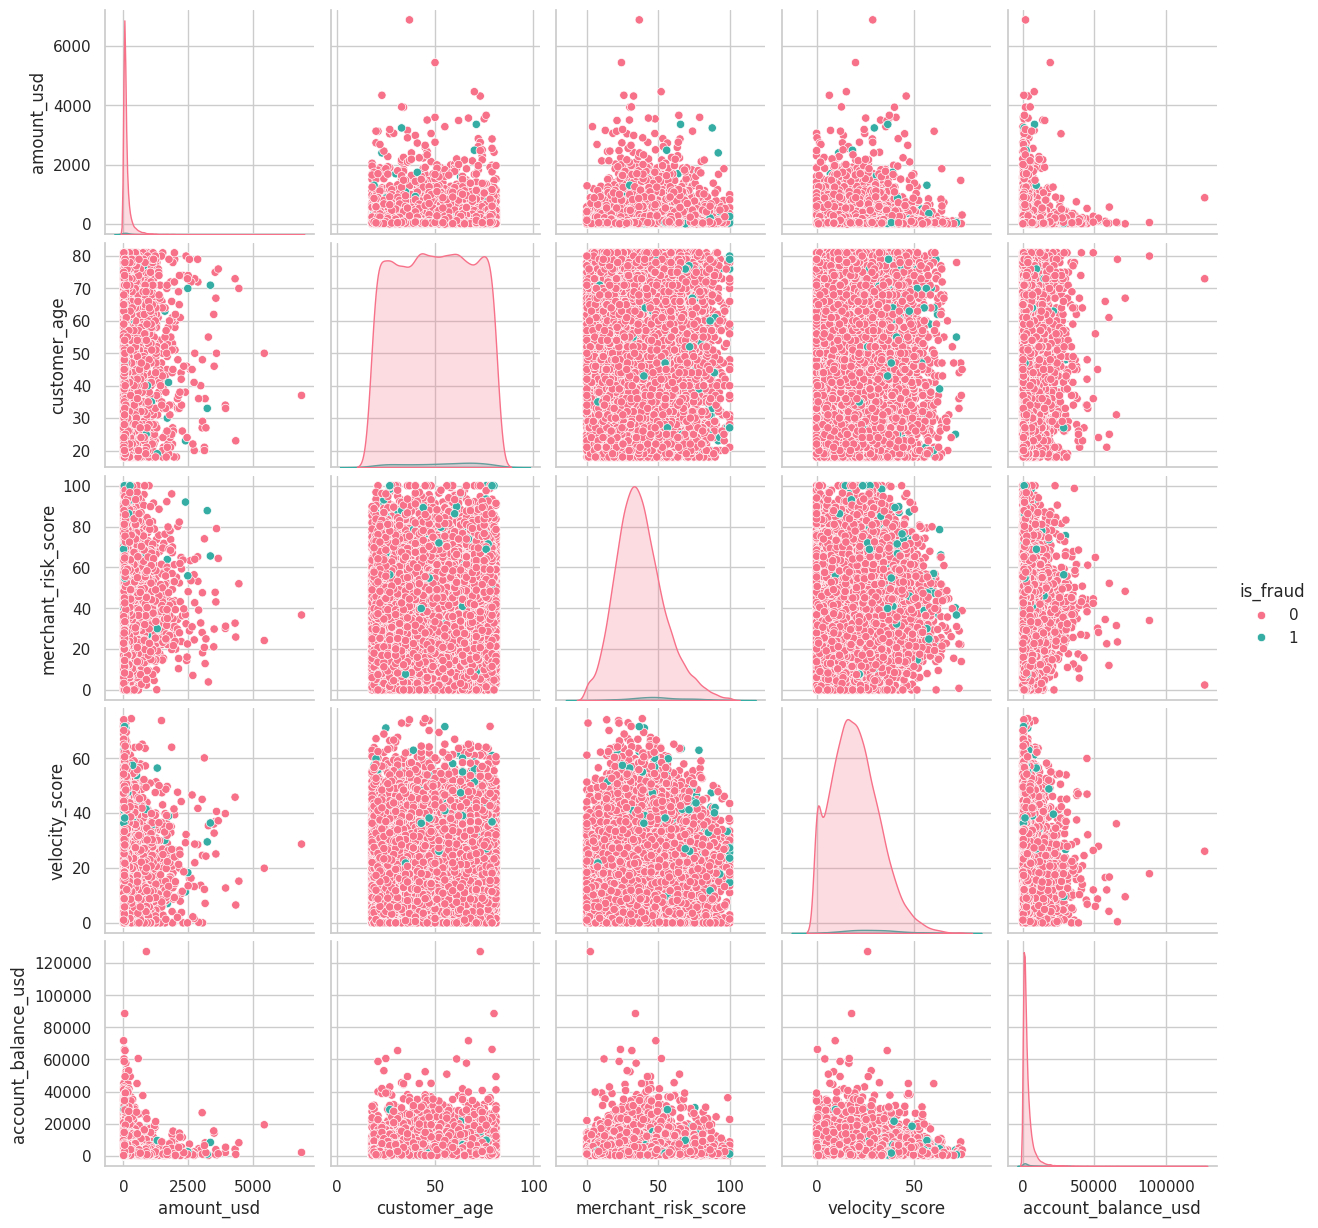

In [30]:
selected = [
    "amount_usd",
    "customer_age",
    "merchant_risk_score",
    "velocity_score",
    "account_balance_usd",
    "is_fraud"
]

sns.pairplot(
    df[selected],
    hue="is_fraud",
    palette="husl"
)

plt.show()

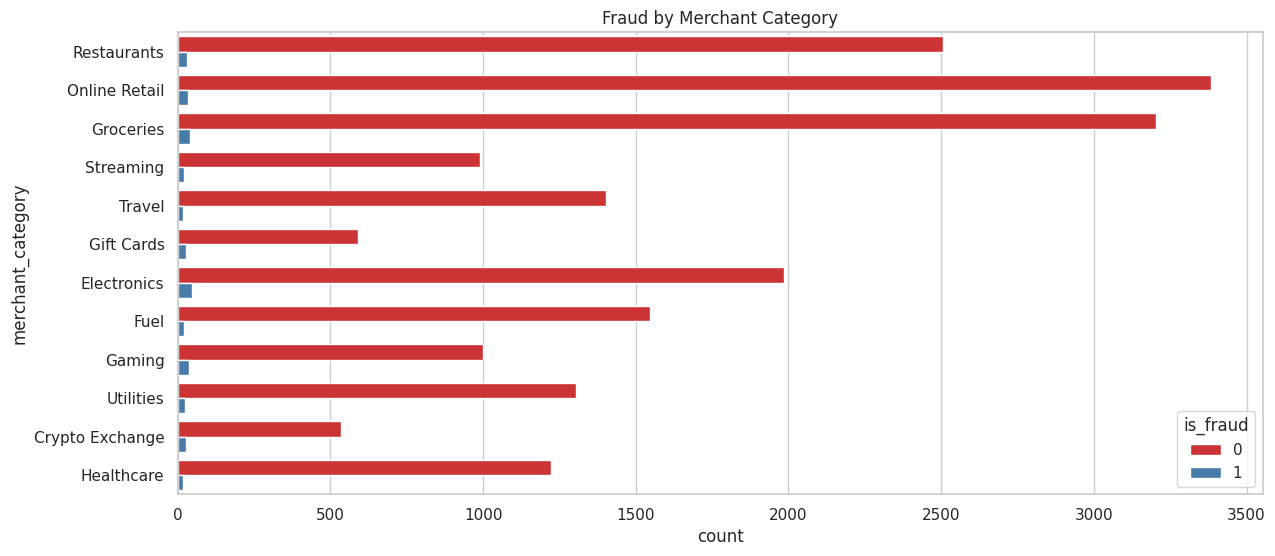

In [31]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="merchant_category",
    hue="is_fraud",
    palette="Set1"
)

plt.title("Fraud by Merchant Category")

plt.show()

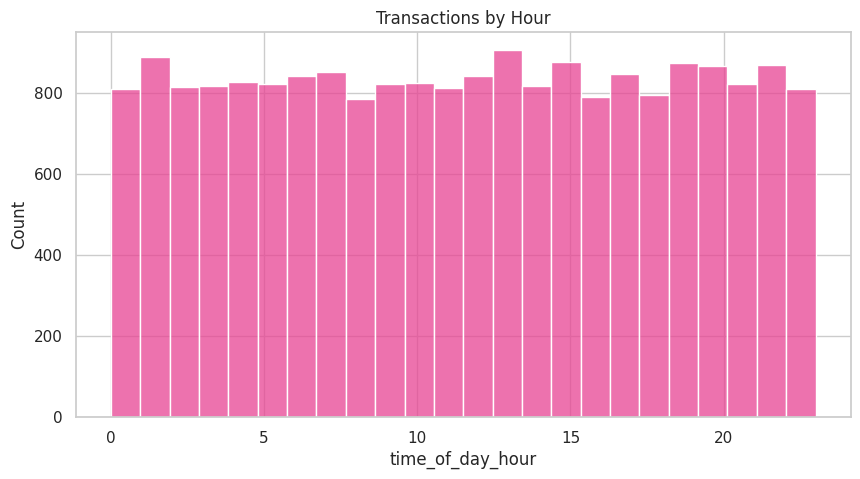

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["time_of_day_hour"],
    bins=24,
    color="#E84393"
)

plt.title("Transactions by Hour")

plt.show()

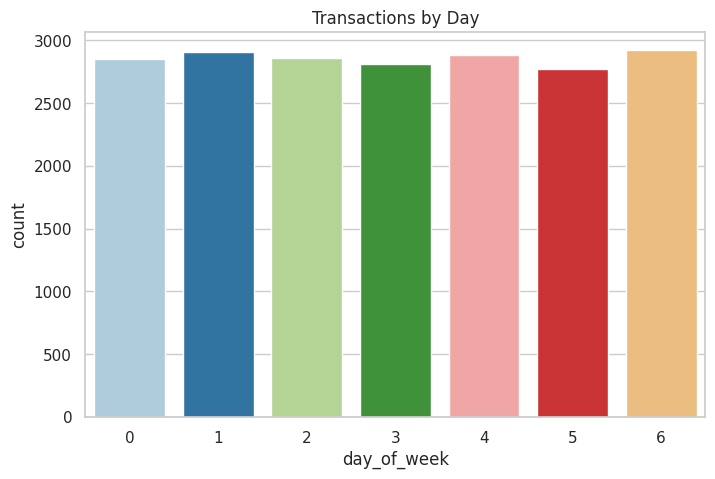

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="day_of_week",
    palette="Paired"
)

plt.title("Transactions by Day")

plt.show()

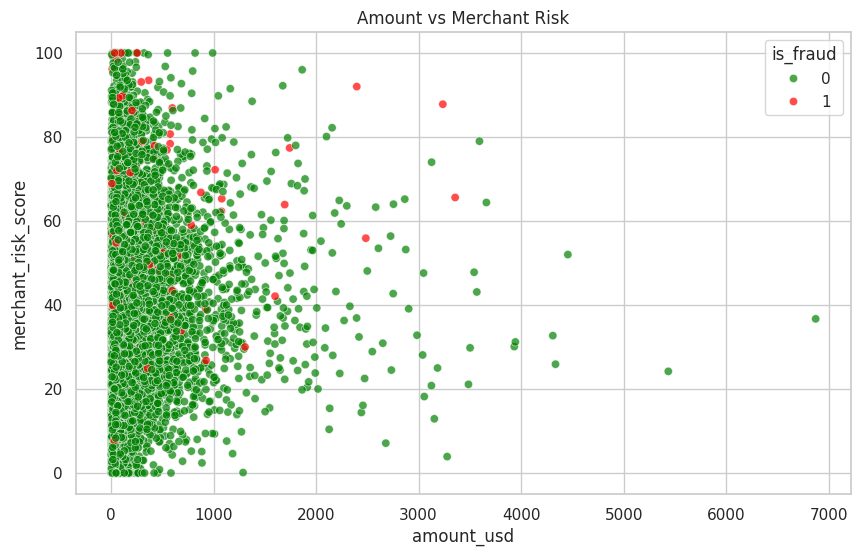

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="amount_usd",
    y="merchant_risk_score",
    hue="is_fraud",
    palette=["green","red"],
    alpha=0.7
)

plt.title("Amount vs Merchant Risk")

plt.show()

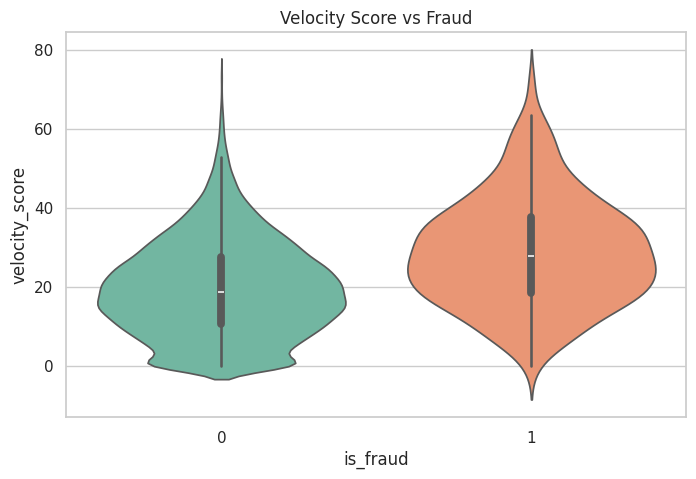

In [35]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="is_fraud",
    y="velocity_score",
    palette="Set2"
)

plt.title("Velocity Score vs Fraud")

plt.show()

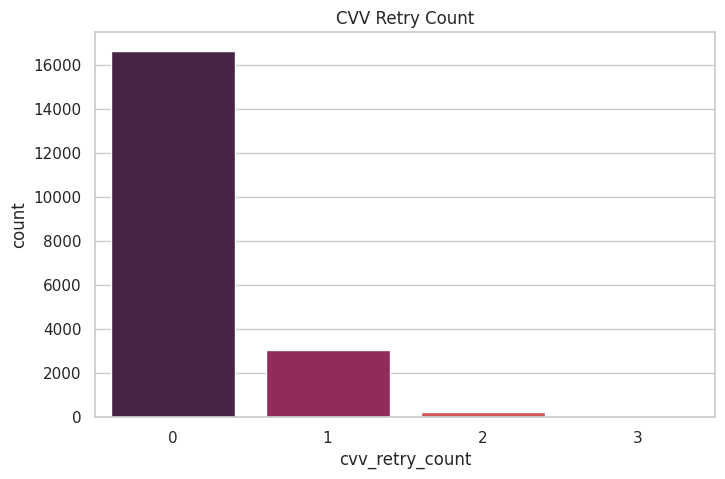

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="cvv_retry_count",
    palette="rocket"
)

plt.title("CVV Retry Count")

plt.show()

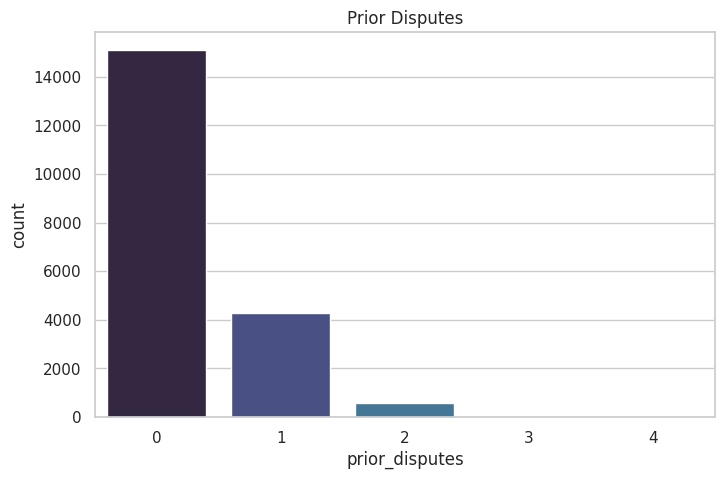

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="prior_disputes",
    palette="mako"
)

plt.title("Prior Disputes")

plt.show()

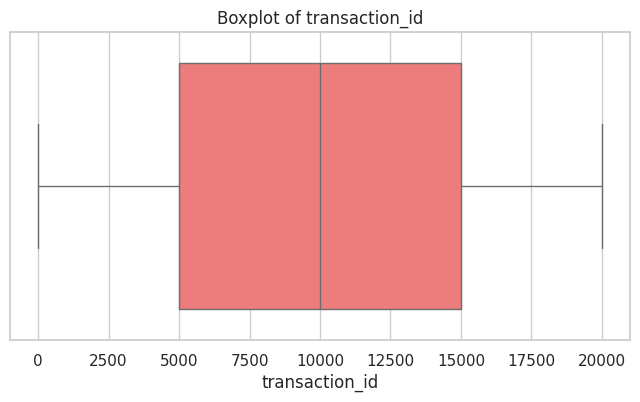

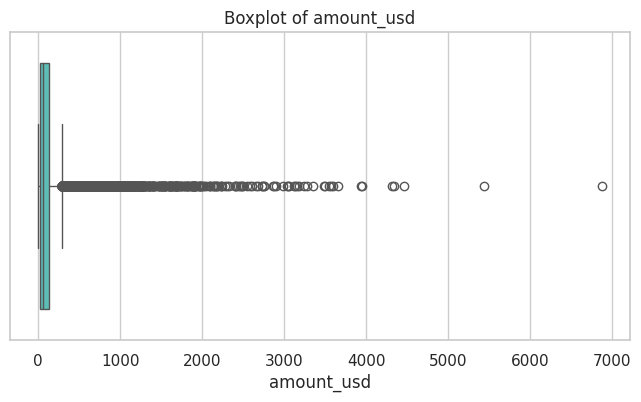

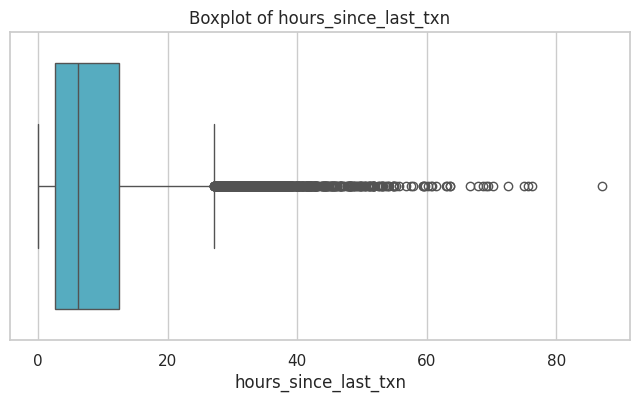

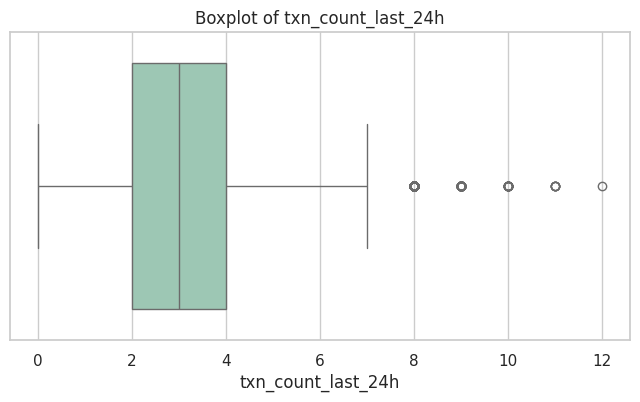

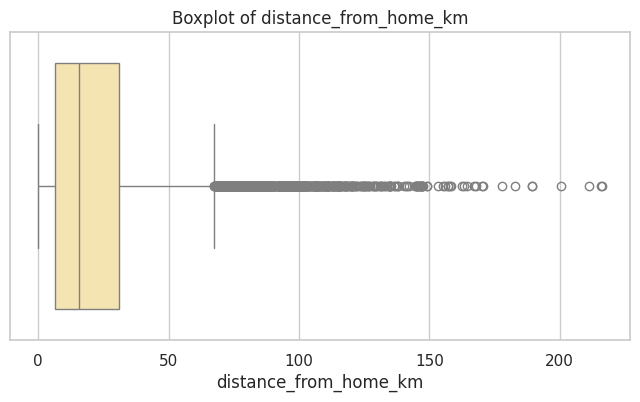

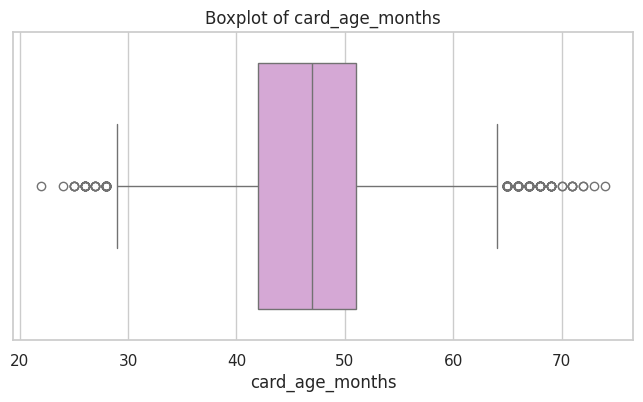

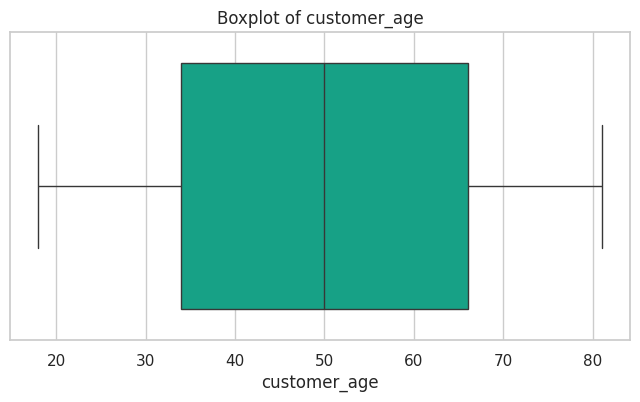

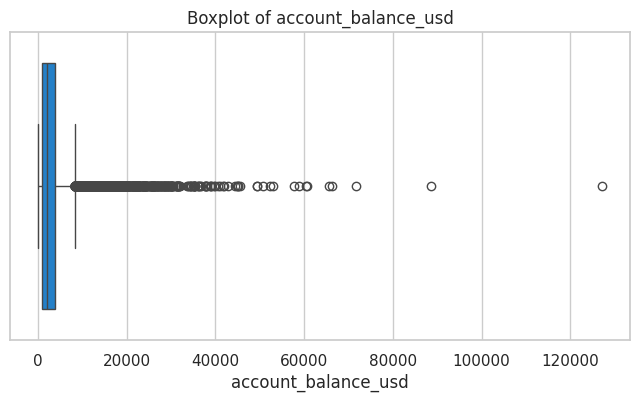

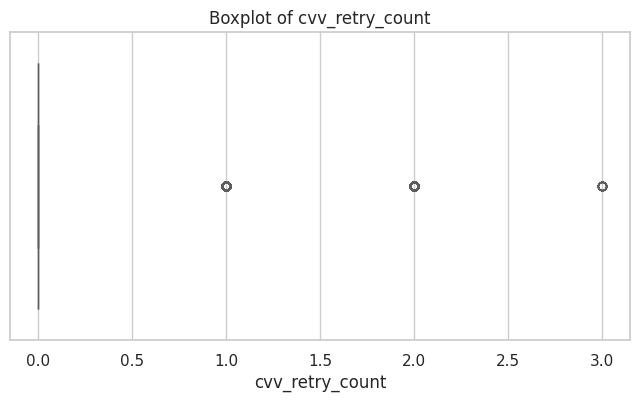

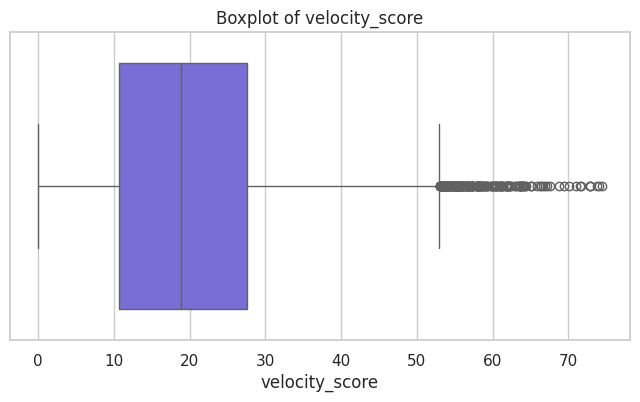

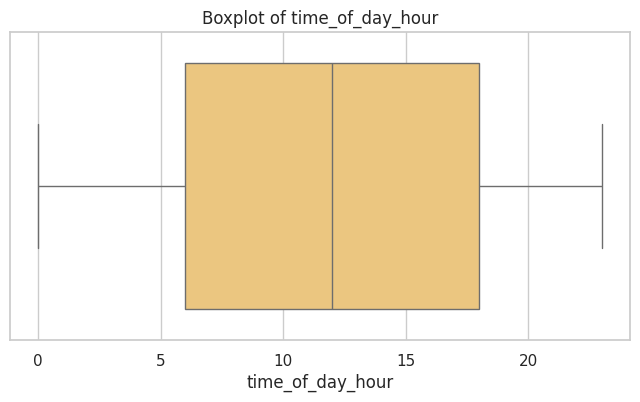

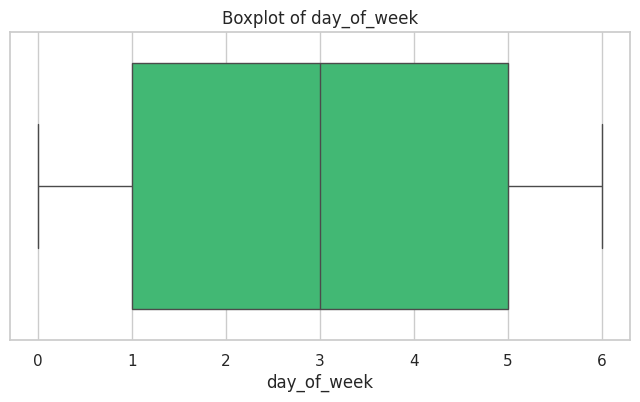

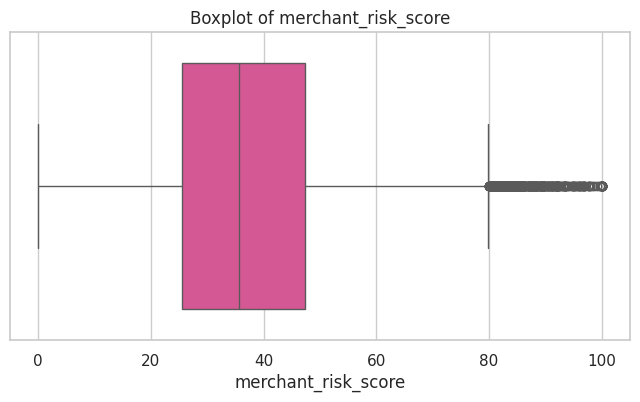

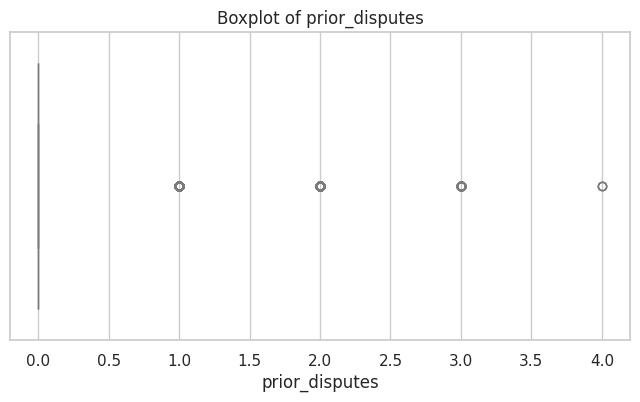

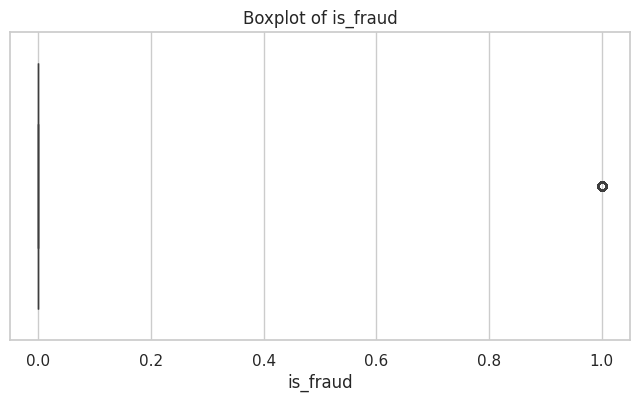

In [38]:
for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=colors[i % len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

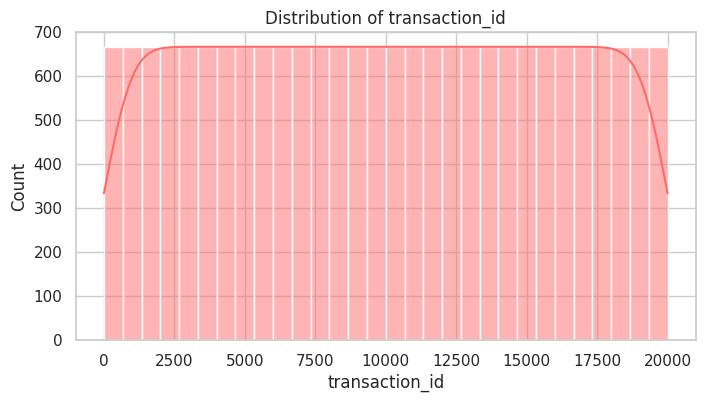

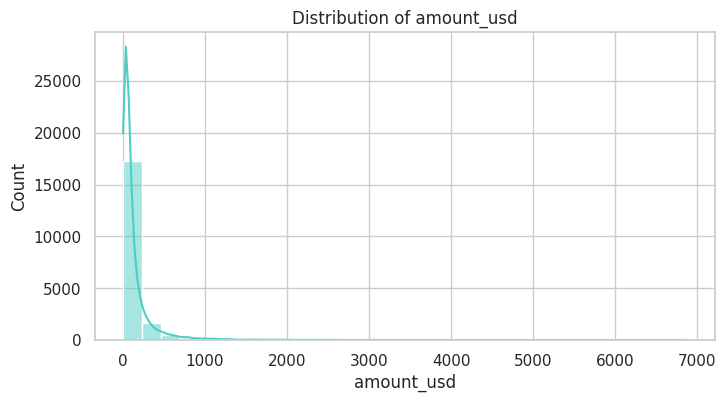

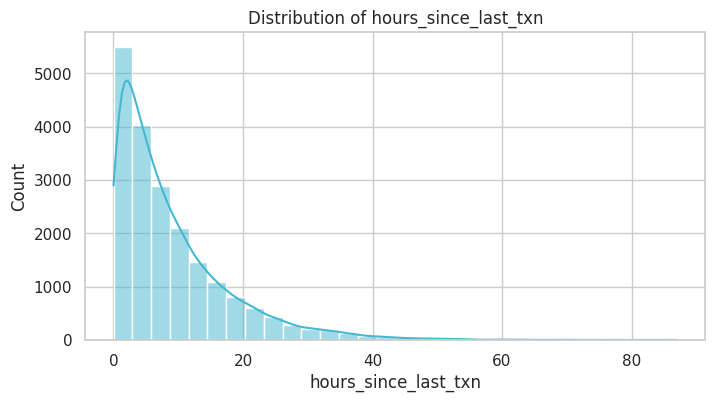

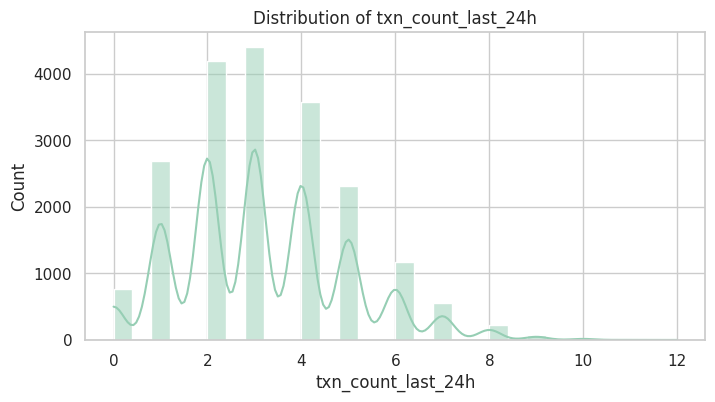

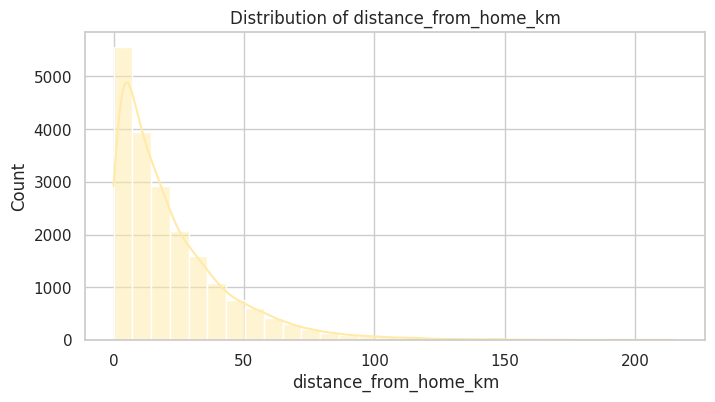

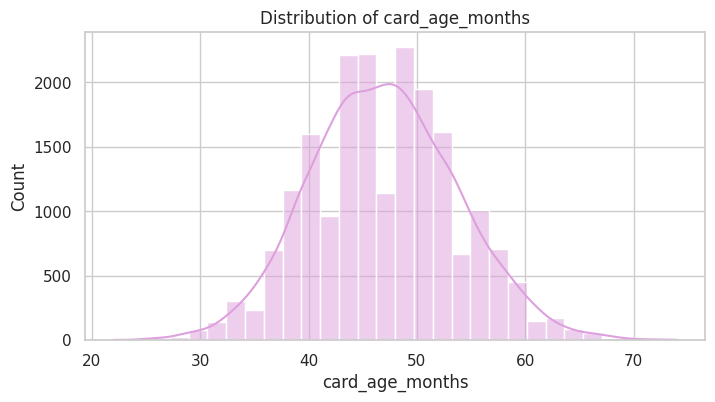

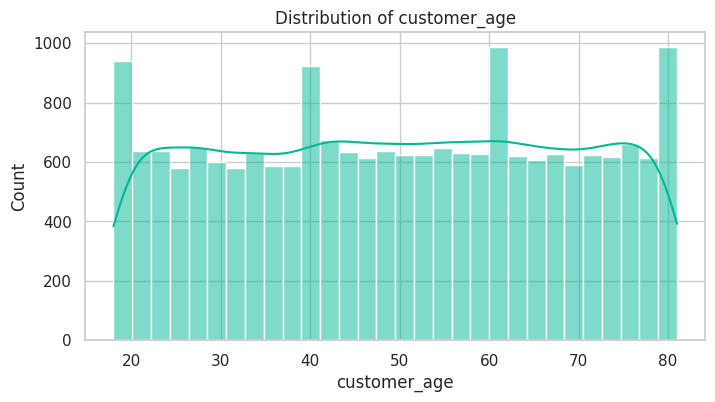

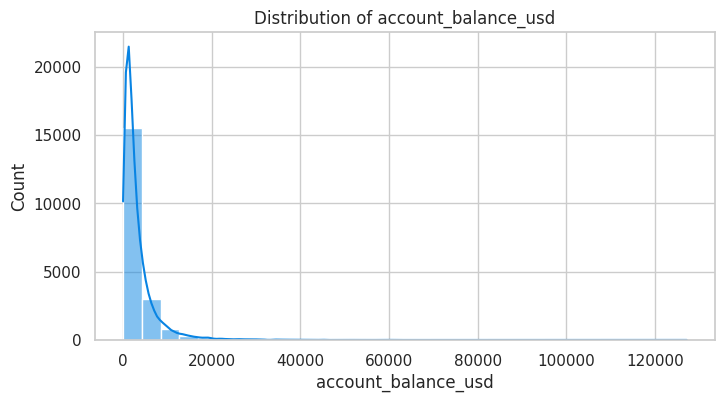

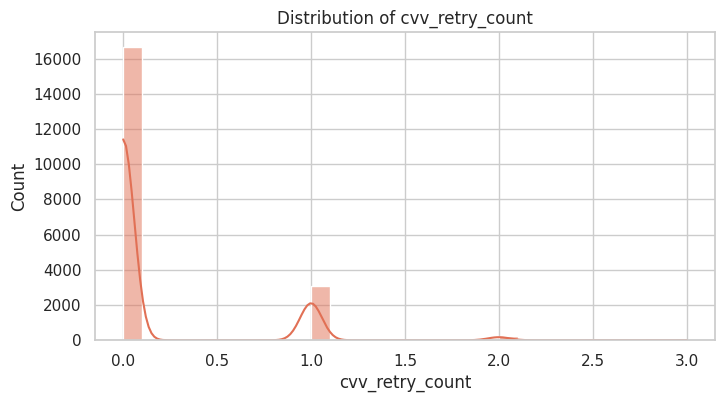

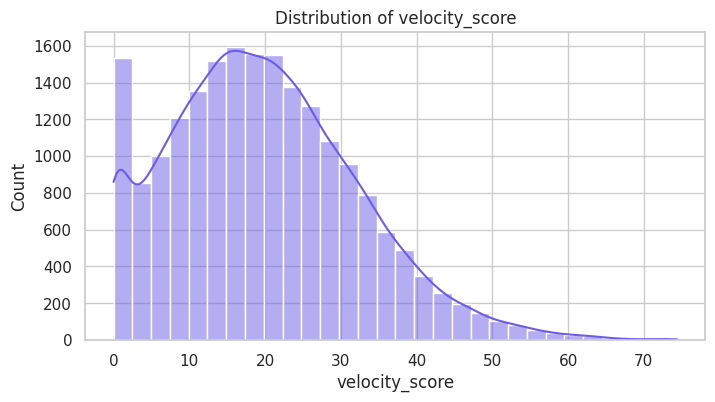

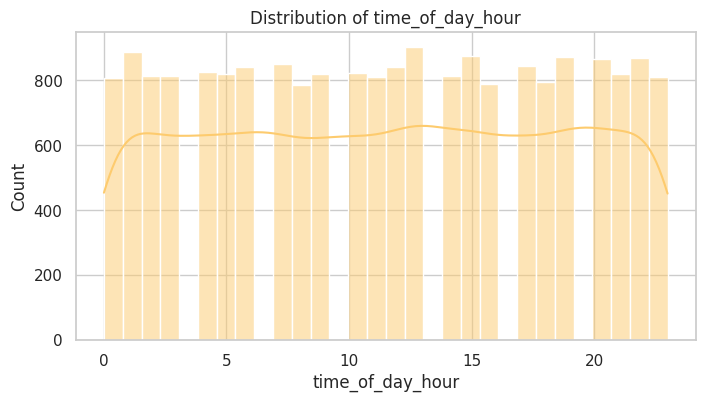

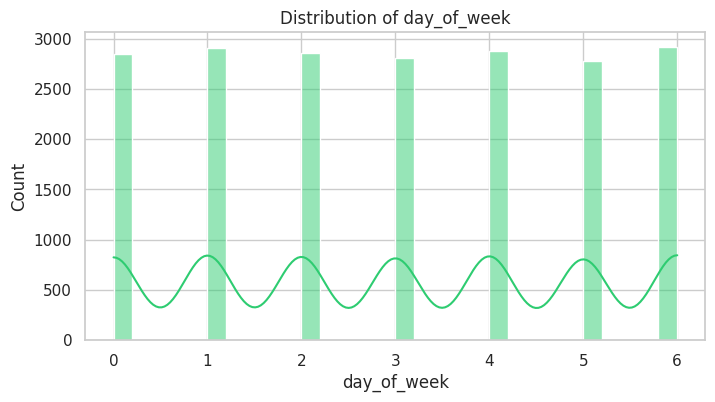

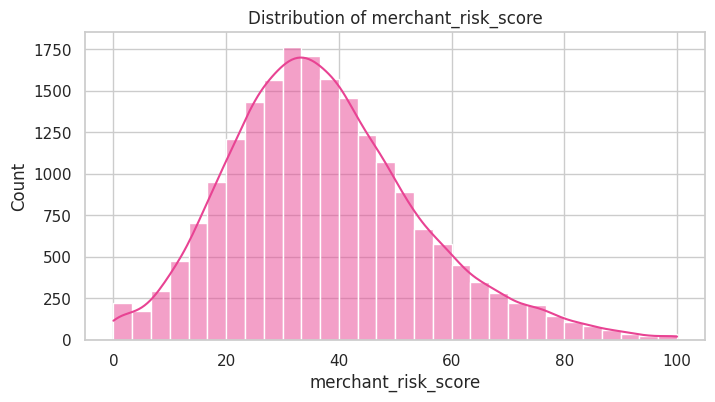

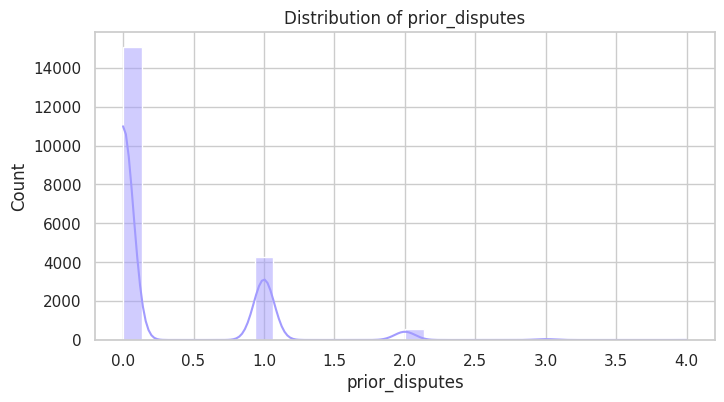

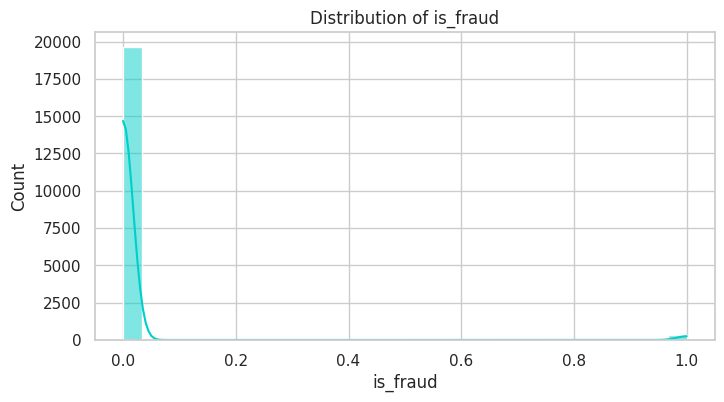

In [39]:
for i,col in enumerate(numerical_columns):

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color=colors[i % len(colors)]
    )

    plt.title(f"Distribution of {col}")

    plt.show()

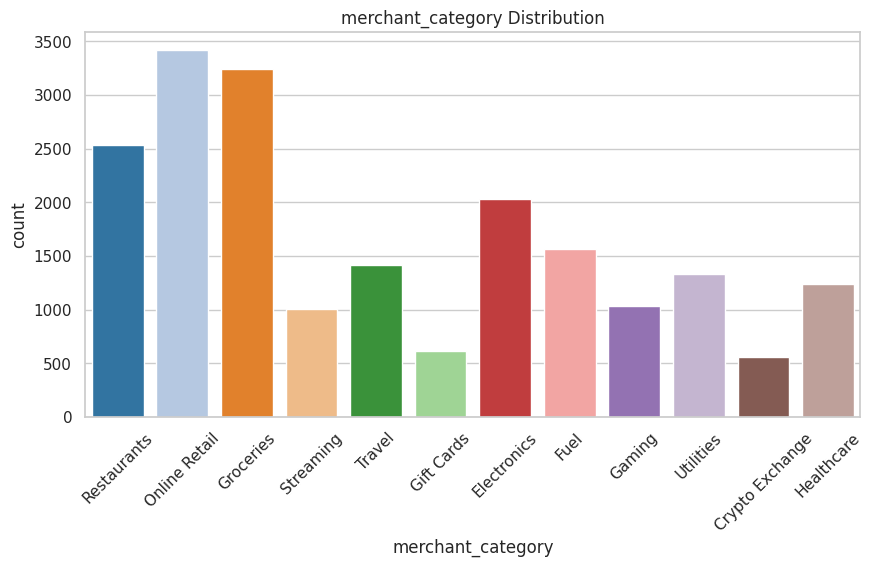

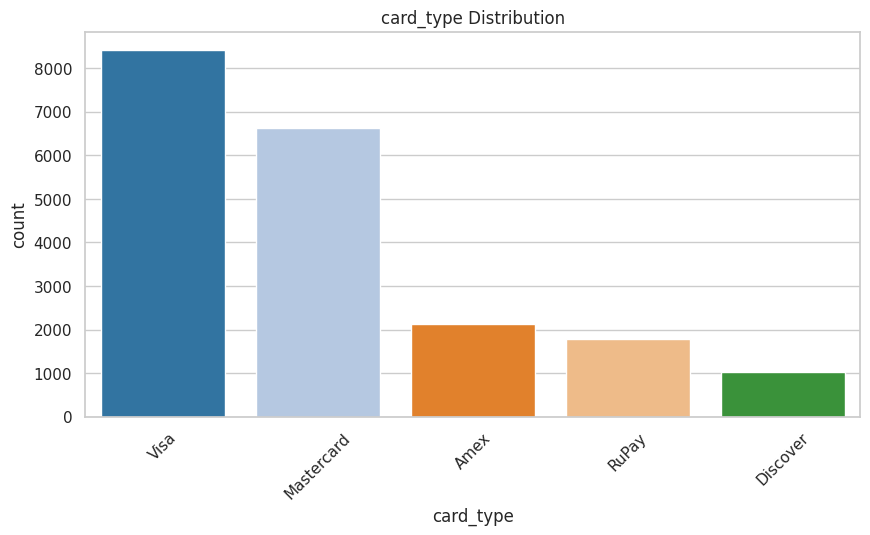

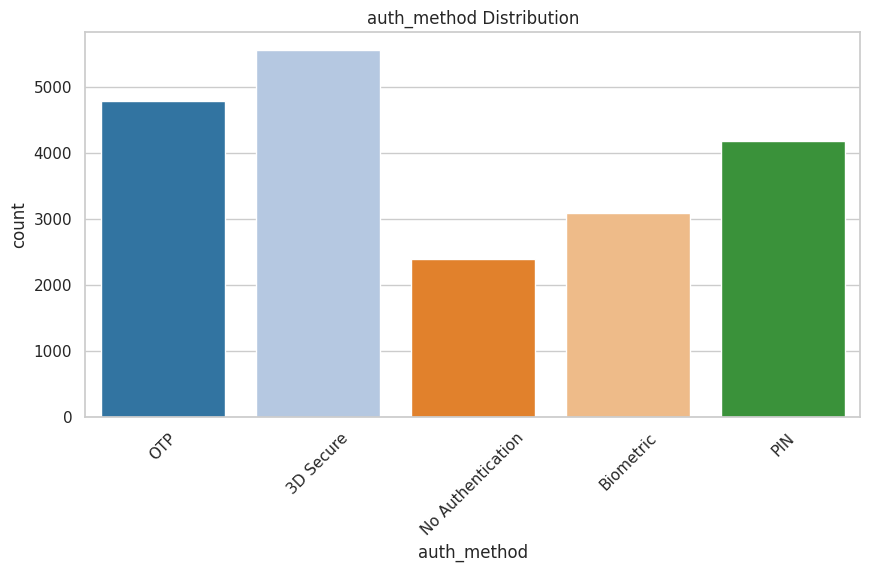

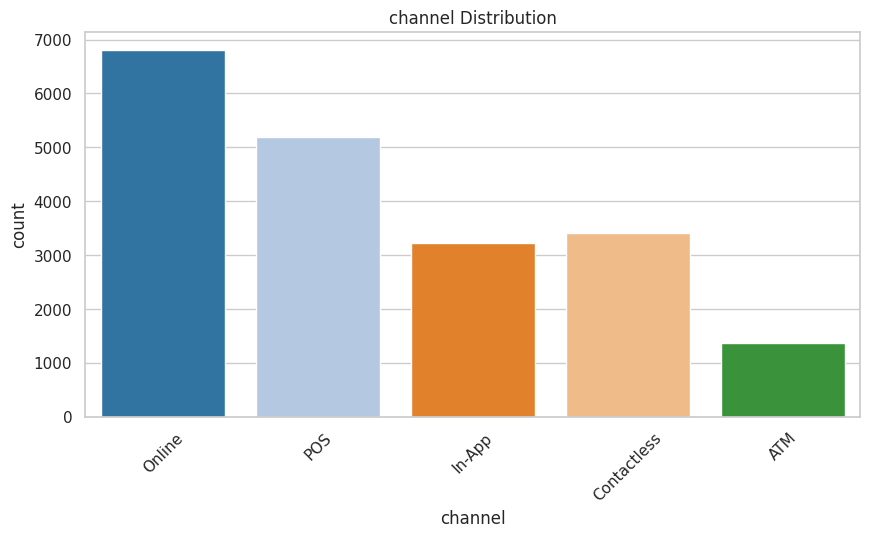

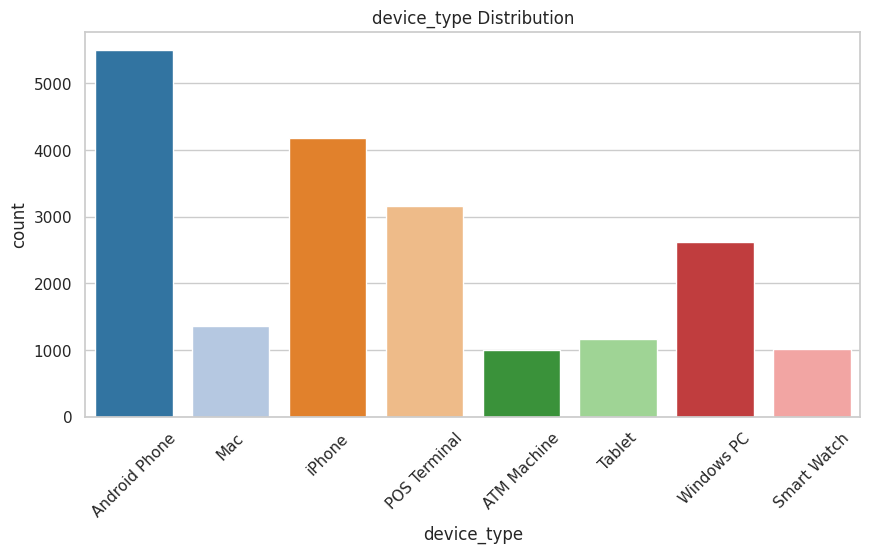

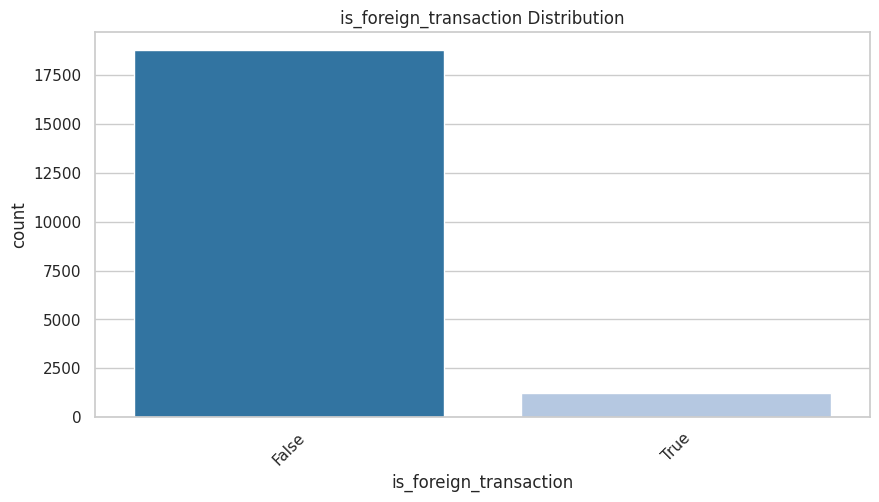

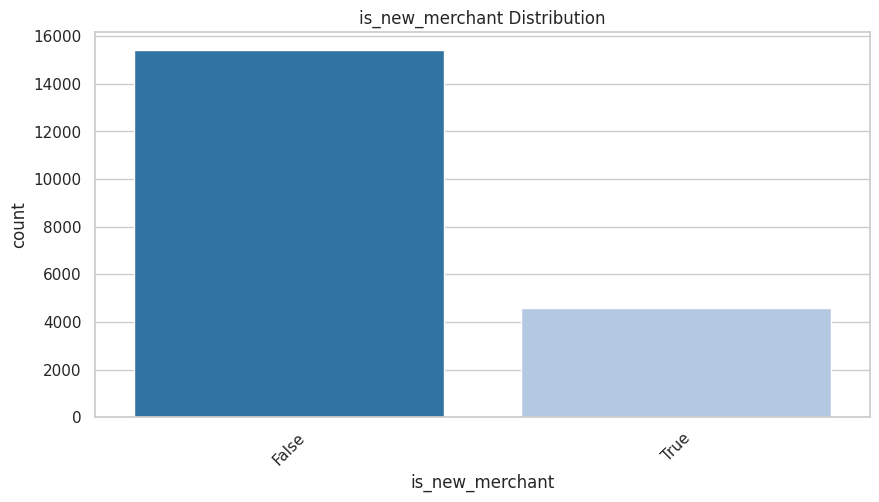

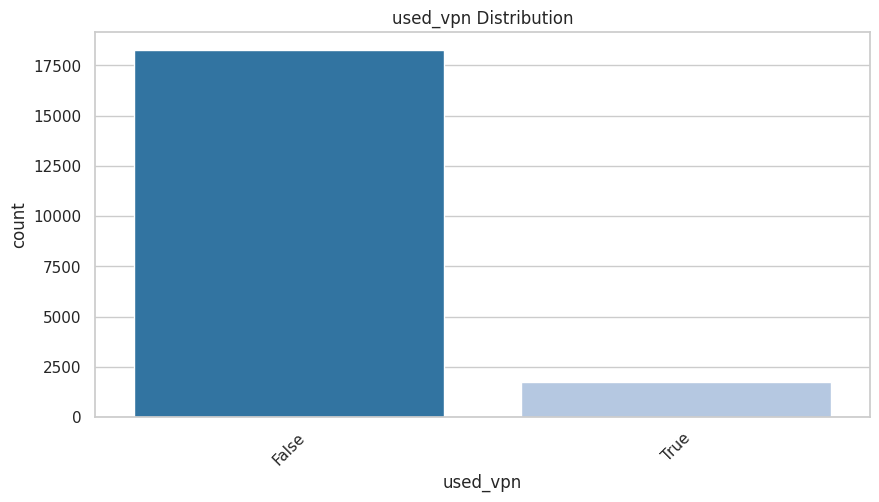

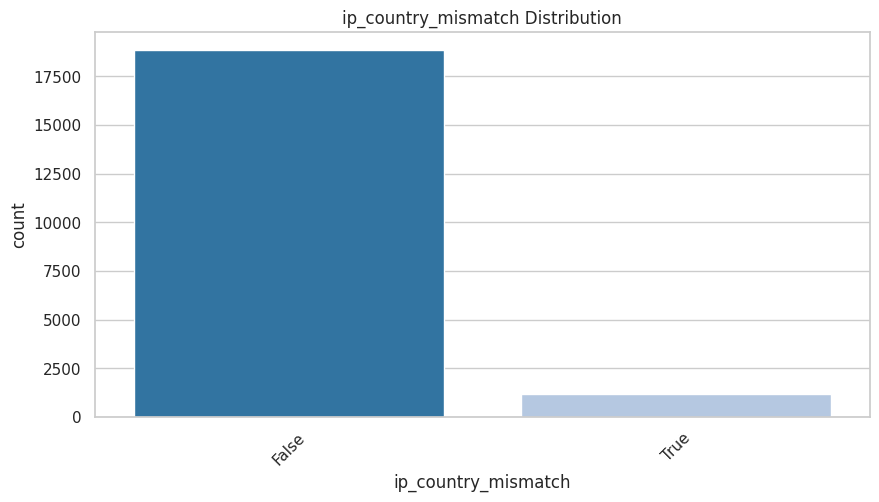

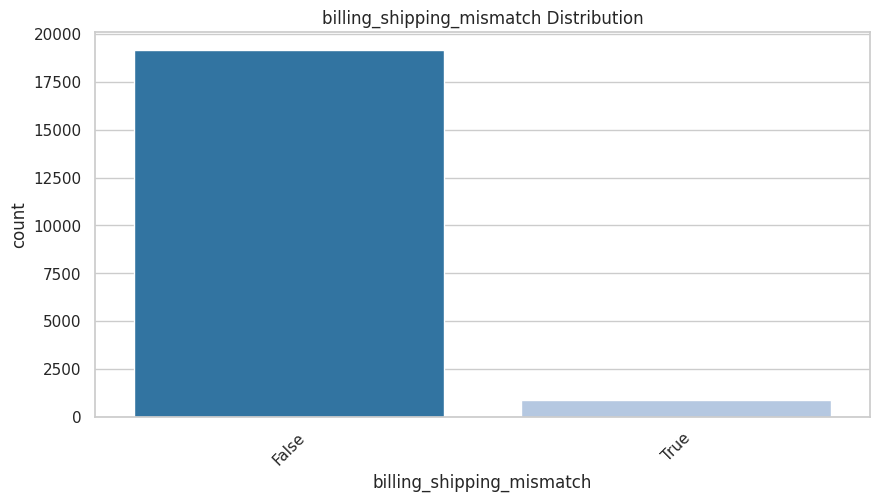

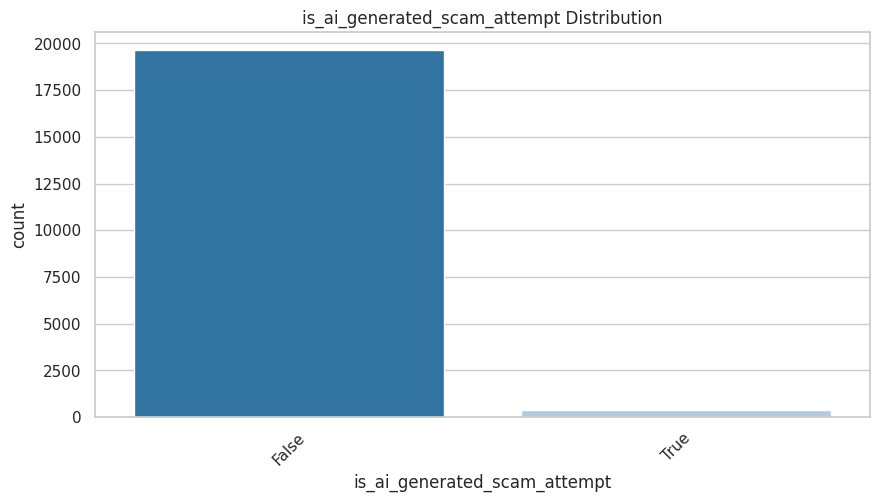

In [40]:
for i,col in enumerate(categorical_columns):

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=col,
        palette="tab20"
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} Distribution")

    plt.show()

## Feature engineering

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df_ml = df.copy()

In [43]:
df_ml.drop("transaction_id", axis=1, inplace=True)

In [44]:
for col in df_ml.columns:

    if df_ml[col].dtype=="object":

        df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)

    else:

        df_ml[col].fillna(df_ml[col].median(), inplace=True)

In [45]:
le = LabelEncoder()

for col in df_ml.columns:

    if df_ml[col].dtype=="object":

        df_ml[col] = le.fit_transform(df_ml[col])

In [46]:
X = df_ml.drop("is_fraud", axis=1)

y = df_ml["is_fraud"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(16000, 24)
(4000, 24)


In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from xgboost import XGBClassifier

In [50]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(probability=True),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

}

In [51]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    proba = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test,pred)

    precision = precision_score(y_test,pred)

    recall = recall_score(y_test,pred)

    f1 = f1_score(y_test,pred)

    roc = roc_auc_score(y_test,proba)

    results.append([

        name,

        accuracy*100,

        precision*100,

        recall*100,

        f1*100,

        roc*100

    ])

In [52]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy (%)",

        "Precision (%)",

        "Recall (%)",

        "F1 Score (%)",

        "ROC AUC (%)"

    ]

)

results_df = results_df.sort_values(

    by="Accuracy (%)",

    ascending=False

)

print(results_df)

                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
0  Logistic Regression        98.525      80.000000   17.647059     28.915663   
5    Gradient Boosting        98.400      66.666667   11.764706     20.000000   
9              XGBoost        98.350      60.000000    8.823529     15.384615   
1                  KNN        98.325     100.000000    1.470588      2.898551   
6             AdaBoost        98.325      60.000000    4.411765      8.219178   
3        Random Forest        98.325     100.000000    1.470588      2.898551   
8                  SVM        98.300       0.000000    0.000000      0.000000   
4          Extra Trees        98.275       0.000000    0.000000      0.000000   
2        Decision Tree        97.125      15.942029   16.176471     16.058394   
7          Naive Bayes        91.825      11.799410   58.823529     19.656020   

   ROC AUC (%)  
0    95.349246  
5    92.577120  
9    91.421070  
1    62.183592  
6    93.097922  
3    9

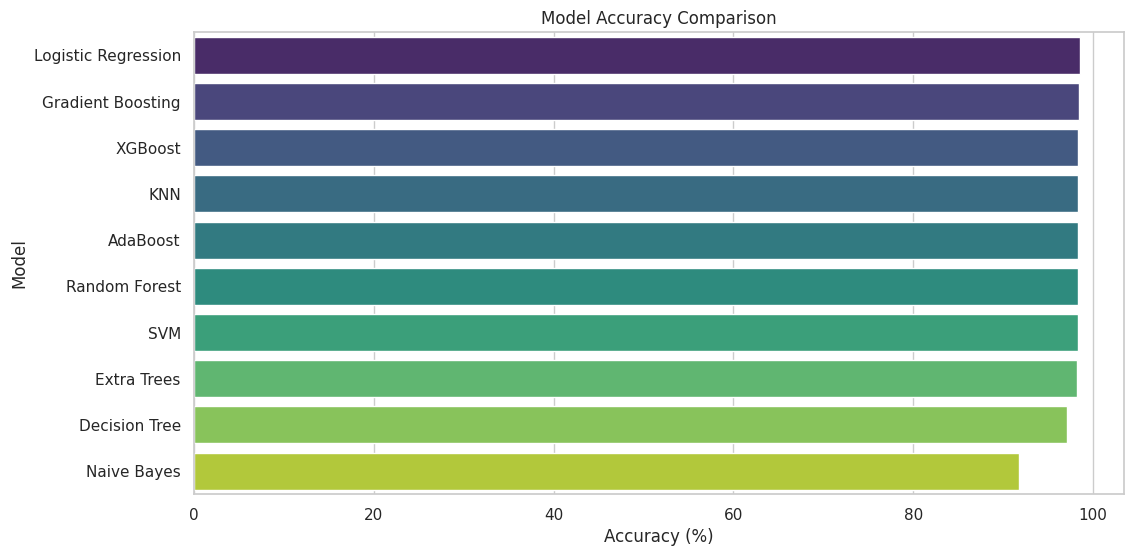

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="Accuracy (%)",

    y="Model",

    palette="viridis"

)

plt.title("Model Accuracy Comparison")

plt.show()

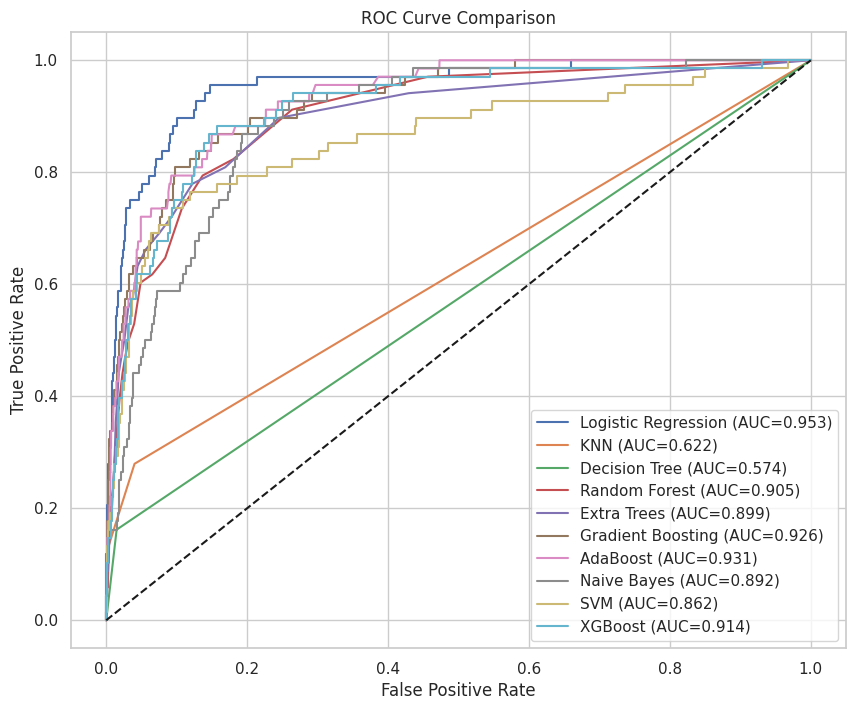

In [54]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    prob = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,prob)

    auc = roc_auc_score(y_test,prob)

    plt.plot(

        fpr,

        tpr,

        label=f"{name} (AUC={auc:.3f})"

    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

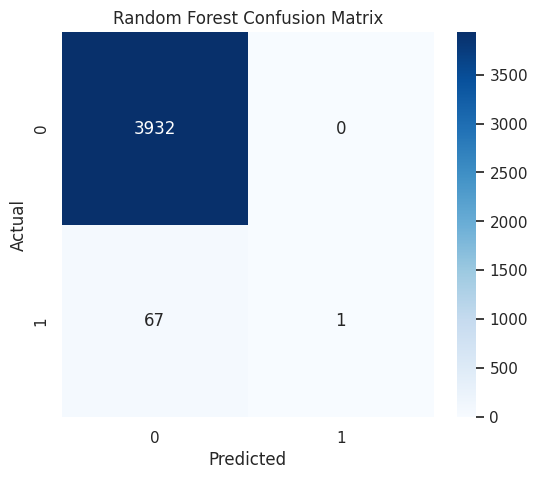

In [55]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train,y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [56]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       1.00      0.01      0.03        68

    accuracy                           0.98      4000
   macro avg       0.99      0.51      0.51      4000
weighted avg       0.98      0.98      0.98      4000



In [57]:
accuracy = accuracy_score(y_test,pred)

print("="*50)

print(f"Accuracy : {accuracy*100:.2f}%")

print(f"Precision : {precision_score(y_test,pred)*100:.2f}%")

print(f"Recall : {recall_score(y_test,pred)*100:.2f}%")

print(f"F1 Score : {f1_score(y_test,pred)*100:.2f}%")

print(f"ROC AUC : {roc_auc_score(y_test,best_model.predict_proba(X_test)[:,1])*100:.2f}%")

print("="*50)

Accuracy : 98.32%
Precision : 100.00%
Recall : 1.47%
F1 Score : 2.90%
ROC AUC : 90.45%


## Thank you...pls upvote!!!!!!!!!!!!!